# Final Project - Text Mining for AI

This notebook contains experiments and results for:
- sentiment analysis
- topic analysis
- named entity recognition/classification

# Imports

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import os
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ======================================
# SENTIMENT ANALYSIS
# ======================================

Dataset Loading and Preprocessing

In [38]:
data = []

dataset_path = "airlinetweets"

for label in ["positive", "negative", "neutral"]:
    folder_path = os.path.join(dataset_path, label)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        with open(file_path, "r", encoding="utf-8") as file:
            text = file.read()

            data.append({
                "text": text,
                "label": label
            })

df = pd.DataFrame(data)

In [39]:
df.head()

,text,label
0,"""@AmericanAir just curious. Thanks for the res...",positive
1,@united thanks for all the help! Totally appre...,positive
2,@JetBlue thanks. Line moved quick. Already done.,positive
3,@AmericanAir Aww cool! It's nice to know they ...,positive
4,@SouthwestAir Great job with the Passbook inte...,positive


In [40]:
print(df["label"].value_counts())

label
negative    1750
neutral     1515
positive    1490
Name: count, dtype: int64


SVM + TF-IDF Sentiment Analysis

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [42]:
# Create and train the model
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [43]:
# Predictions
predictions = model.predict(X_test)

In [44]:
# Evaluation (classification report)
print(classification_report(y_test, predictions))
svm_report = classification_report(y_test, predictions, output_dict=True)

              precision    recall  f1-score   support

    negative       0.84      0.90      0.87       328
     neutral       0.78      0.80      0.79       296
    positive       0.90      0.80      0.85       327

    accuracy                           0.84       951
   macro avg       0.84      0.84      0.84       951
weighted avg       0.84      0.84      0.84       951



The TF-IDF + SVM model achieved an accuracy of 84%. The model performs best on negative and positive sentiment, while neutral sentiment is slightly more difficult to classify.

In [45]:
for i in range(5):
    print("TEXT:", X_test.iloc[i])
    print("PREDICTED:", predictions[i])
    print("ACTUAL:", y_test.iloc[i])
    print("-" * 50)

TEXT: @SouthwestAir @SouthwestOliver that's a great FA right there.
PREDICTED: positive
ACTUAL: positive
--------------------------------------------------
TEXT: "@united flight landed 13 hours ago
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------
TEXT: "@united at its worse. Can't figure how to pack plane
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------
TEXT: @AmericanAir Am I upgraded on my next flight?
PREDICTED: neutral
ACTUAL: neutral
--------------------------------------------------
TEXT: @united that's cool - now what?
PREDICTED: negative
ACTUAL: negative
--------------------------------------------------


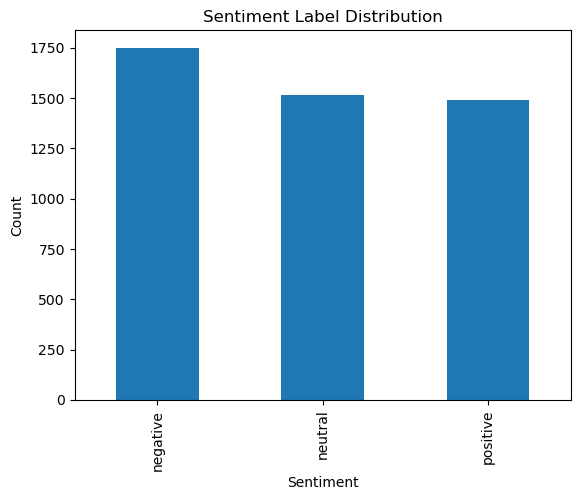

In [ ]:
df["label"].value_counts().plot(kind="bar")

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()


DistilBERT Sentiment Analysis


In [47]:
# DistilBERT Sentiment Analysis using HuggingFace Transformers
from transformers import pipeline

# Load pre-trained DistilBERT sentiment model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Predict on test set
distilbert_predictions = []
distilbert_scores = []

for text in X_test:
    result = sentiment_model(text)
    label = result[0]['label']
    score = result[0]['score']
    
    # Convert to 3-class: use confidence threshold for neutral
    if score < 0.65:
        pred_label = 'neutral'
    elif label == 'POSITIVE':
        pred_label = 'positive'
    else:  # NEGATIVE
        pred_label = 'negative'
    
    distilbert_predictions.append(pred_label)
    distilbert_scores.append(score)

distilbert_predictions = pd.Series(distilbert_predictions)
distilbert_report = classification_report(
    y_test,
    distilbert_predictions,
    output_dict=True
)

print(classification_report(y_test, distilbert_predictions))

Device set to use mps:0


              precision    recall  f1-score   support

    negative       0.53      0.86      0.66       328
     neutral       0.55      0.05      0.10       296
    positive       0.74      0.88      0.80       327

    accuracy                           0.62       951
   macro avg       0.61      0.60      0.52       951
weighted avg       0.61      0.62      0.53       951



Save results

In [48]:
# Save Report
report_df = pd.DataFrame(distilbert_report).transpose()

report_df.to_csv("distilbert_classification_report.csv")

print("Saved to distilbert_classification_report.csv")

Saved to distilbert_classification_report.csv


In [49]:
# Save predictions
results_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": distilbert_predictions.values,
    "confidence": distilbert_scores
})

results_df.to_csv("distilbert_predictions.csv", index=False)

print("Saved to distilbert_predictions.csv")

Saved to distilbert_predictions.csv


In [50]:
# Inspect missclassified examples
errors = results_df[results_df["actual"] != results_df["predicted"]]

errors.to_csv("distilbert_errors.csv", index=False)

Result Comparison and Error Analysis

In [51]:
# ======================================
# RESULT COMPARISON
# ======================================

comparison_results = pd.DataFrame([
    {
        "model": "TF-IDF + SVM",
        "accuracy": svm_report["accuracy"],
        "negative_f1": svm_report["negative"]["f1-score"],
        "neutral_f1": svm_report["neutral"]["f1-score"],
        "positive_f1": svm_report["positive"]["f1-score"]
    },
    {
        "model": "DistilBERT",
        "accuracy": distilbert_report["accuracy"],
        "negative_f1": distilbert_report["negative"]["f1-score"],
        "neutral_f1": distilbert_report["neutral"]["f1-score"],
        "positive_f1": distilbert_report["positive"]["f1-score"]
    }
])

comparison_results

,model,accuracy,negative_f1,neutral_f1,positive_f1
0,TF-IDF + SVM,0.837014,0.870588,0.789386,0.846527
1,DistilBERT,0.616193,0.658140,0.098462,0.800558


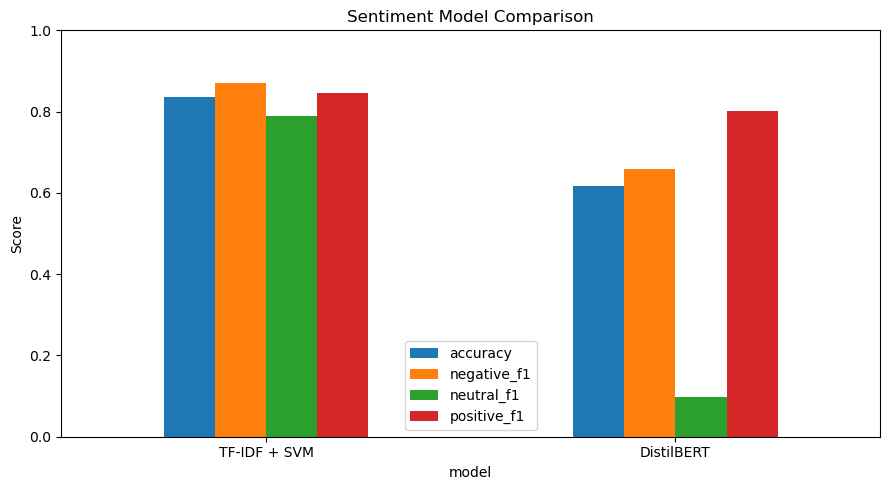

In [52]:
comparison_results.set_index("model").plot(kind="bar", figsize=(9, 5))

plt.title("Sentiment Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
# Load test set
test_df = pd.read_csv("sentiment-topic-test.tsv", sep="\t")
X_test_sent = test_df["sentence"].values
y_test_sent = test_df["sentiment"].values

print(f"Test set size: {len(X_test_sent)} sentences")
print(f"Class distribution:\n{pd.Series(y_test_sent).value_counts()}")

# SVM predictions on test set
svm_test_predictions = model.predict(X_test_sent)

# DistilBERT predictions on test set
distilbert_test_predictions = []

for text in X_test_sent:
    result = sentiment_model(text)
    label = result[0]["label"]
    score = result[0]["score"]
    
    if score < 0.65:
        pred_label = "neutral"
    elif label == "POSITIVE":
        pred_label = "positive"
    else:
        pred_label = "negative"
    
    distilbert_test_predictions.append(pred_label)

distilbert_test_predictions = pd.Series(distilbert_test_predictions).values

# Classification reports
print("\n=== SVM Results on Test Set ===")
svm_test_report = classification_report(y_test_sent, svm_test_predictions, output_dict=True)
print(classification_report(y_test_sent, svm_test_predictions))

print("\n=== DistilBERT Results on Test Set ===")
distilbert_test_report = classification_report(y_test_sent, distilbert_test_predictions, output_dict=True)
print(classification_report(y_test_sent, distilbert_test_predictions))

Test set size: 18 sentences
Class distribution:
positive    6
neutral     6
negative    6
Name: count, dtype: int64

=== SVM Results on Test Set ===
              precision    recall  f1-score   support

    negative       0.33      0.50      0.40         6
     neutral       0.00      0.00      0.00         6
    positive       0.57      0.67      0.62         6

    accuracy                           0.39        18
   macro avg       0.30      0.39      0.34        18
weighted avg       0.30      0.39      0.34        18


=== DistilBERT Results on Test Set ===
              precision    recall  f1-score   support

    negative       0.56      0.83      0.67         6
     neutral       0.00      0.00      0.00         6
    positive       0.67      1.00      0.80         6

    accuracy                           0.61        18
   macro avg       0.41      0.61      0.49        18
weighted avg       0.41      0.61      0.49        18



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-pa

Test Set Performance Comparison:
          model  accuracy  negative_f1  neutral_f1  positive_f1
0  TF-IDF + SVM  0.388889     0.400000         0.0     0.615385
1    DistilBERT  0.611111     0.666667         0.0     0.800000


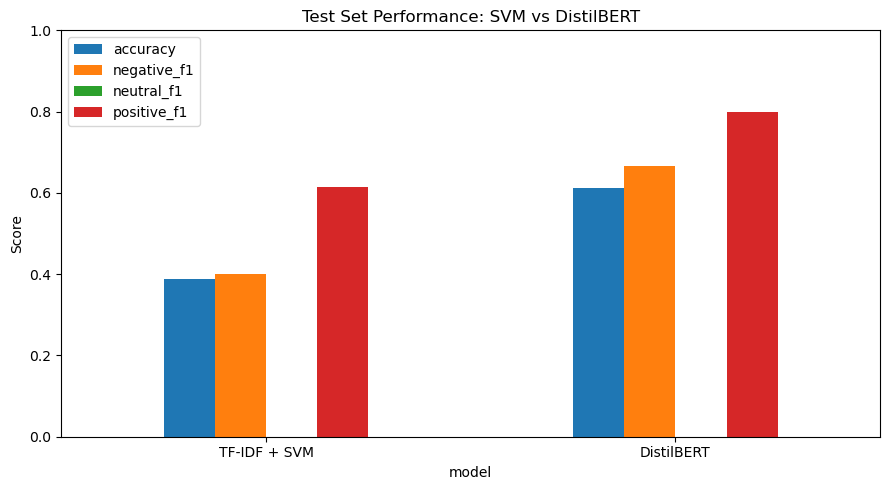

In [54]:
# Compare test set performance
test_comparison = pd.DataFrame([
    {
        "model": "TF-IDF + SVM",
        "accuracy": svm_test_report["accuracy"],
        "negative_f1": svm_test_report["negative"]["f1-score"],
        "neutral_f1": svm_test_report["neutral"]["f1-score"],
        "positive_f1": svm_test_report["positive"]["f1-score"]
    },
    {
        "model": "DistilBERT",
        "accuracy": distilbert_test_report["accuracy"],
        "negative_f1": distilbert_test_report["negative"]["f1-score"],
        "neutral_f1": distilbert_test_report["neutral"]["f1-score"],
        "positive_f1": distilbert_test_report["positive"]["f1-score"]
    }
])

print("Test Set Performance Comparison:")
print(test_comparison)

test_comparison.set_index("model").plot(kind="bar", figsize=(9, 5))
plt.title("Test Set Performance: SVM vs DistilBERT")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
print("=== TRUE POSITIVES (Both models correct) ===\n")

correct_both = (svm_test_predictions == y_test_sent) & (distilbert_test_predictions == y_test_sent)

for i, (sent, true_label) in enumerate(zip(X_test_sent[correct_both][:3], y_test_sent[correct_both][:3])):
    print(f"Sentence: {sent}")
    print(f"Ground Truth: {true_label}")
    print(f"SVM Pred: {svm_test_predictions[correct_both][i]}, DistilBERT Pred: {distilbert_test_predictions[correct_both][i]}")
    print()

print("\n=== SVM ERRORS ===\n")

svm_errors = svm_test_predictions != y_test_sent

for i, (sent, true_label, pred_label) in enumerate(zip(X_test_sent[svm_errors][:2], y_test_sent[svm_errors][:2], svm_test_predictions[svm_errors][:2])):
    print(f"Sentence: {sent}")
    print(f"Ground Truth: {true_label}, Predicted: {pred_label}")
    print()

print("\n=== DistilBERT ERRORS ===\n")

distilbert_errors = distilbert_test_predictions != y_test_sent

for i, (sent, true_label, pred_label) in enumerate(zip(X_test_sent[distilbert_errors][:2], y_test_sent[distilbert_errors][:2], distilbert_test_predictions[distilbert_errors][:2])):
    print(f"Sentence: {sent}")
    print(f"Ground Truth: {true_label}, Predicted: {pred_label}")
    print()

=== TRUE POSITIVES (Both models correct) ===

Sentence: The atmosphere at the stadium tonight was electric.
Ground Truth: positive
SVM Pred: positive, DistilBERT Pred: positive

Sentence: The game was so intense I forgot to breathe at times. What a win!
Ground Truth: positive
SVM Pred: positive, DistilBERT Pred: positive

Sentence: I could watch this film a hundred times and still find something new to love about it.
Ground Truth: positive
SVM Pred: positive, DistilBERT Pred: positive


=== SVM ERRORS ===

Sentence: It had me hooked from the first chapter.
Ground Truth: positive, Predicted: neutral

Sentence: It’s more of a slow burn than a page-turner, but it’s well-written, I guess.
Ground Truth: neutral, Predicted: negative


=== DistilBERT ERRORS ===

Sentence: It’s more of a slow burn than a page-turner, but it’s well-written, I guess.
Ground Truth: neutral, Predicted: positive

Sentence: It’s split into two timelines, which keeps it interesting but also a bit confusing at times.


# End of notebook